In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
import h5py


In [14]:
import h5py
import numpy as np

file = h5py.File("GOLD_XYZ_OSC.0001_1024.hdf5", "r")

print(list(file.keys()))

['X', 'Y', 'Z']


In [18]:
print(file['X'].shape)

(2555904, 1024, 2)


In [19]:
print(file['Y'].shape)

(2555904, 24)


In [20]:
print(file['Z'].shape)

(2555904, 1)


In [69]:
indices = np.random.choice(total_samples, 5000, replace=False)
indices = np.sort(indices)   

X = file['X'][indices]
Y = file['Y'][indices]
Z = file['Z'][indices]

In [70]:
X

array([[[ 0.5847257 , -1.6029146 ],
        [ 0.5643556 , -0.8622332 ],
        [ 0.6449828 , -0.26420555],
        ...,
        [-0.48597813, -1.2684244 ],
        [ 1.1649756 , -0.31891933],
        [ 1.0132143 , -1.2297897 ]],

       [[ 0.06189313, -0.15409866],
        [-0.30524355, -0.25978035],
        [ 1.3967355 ,  0.92201334],
        ...,
        [ 0.7825433 , -0.2005348 ],
        [-0.5882259 ,  0.6978542 ],
        [ 0.47140807,  0.6115953 ]],

       [[-0.23492788, -0.22398107],
        [-0.29513267,  0.30709973],
        [-0.56540006,  0.43061918],
        ...,
        [ 1.047321  ,  0.7100713 ],
        [-1.1969113 , -0.4284308 ],
        [-0.8414109 ,  0.08839272]],

       ...,

       [[-0.92303455, -0.59802556],
        [-1.0311646 , -0.50113153],
        [-1.1083486 , -0.36141223],
        ...,
        [-0.39600196, -0.80040294],
        [-0.44288754, -0.90361845],
        [-0.41944832, -0.9909266 ]],

       [[-0.5658536 , -0.877335  ],
        [-0.63849425, -0.97

In [71]:
print(X.shape)

(5000, 1024, 2)


In [72]:
print(Y.shape)

(5000, 24)


In [73]:
print(Z.shape)

(5000, 1)


In [74]:
Y

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]], shape=(5000, 24))

In [75]:
y = np.argmax(Y, axis=1)

In [76]:
print("Unique labels:", np.unique(y))

Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [77]:
X = X.reshape(-1, 2, 1024, 1)

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [80]:
model = Sequential([
    Conv2D(64, (1,3), activation='relu', input_shape=(2,1024,1)),
    MaxPooling2D((1,2)),

    Conv2D(128, (1,3), activation='relu'),
    MaxPooling2D((1,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(len(np.unique(y)), activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

d:\bmc\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 2, 1022, 64)    │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 2, 511, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 2, 509, 128)    │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 254, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 65024)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │    16,646,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,677,528 (63.62 MB)

 Trainable params: 16,677,528 (63.62 MB)

 Non-trainable params: 0 (0.00 B)

In [83]:
model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 409ms/step - accuracy: 0.9195 - loss: 0.5072 - val_accuracy: 0.1870 - val_loss: 3.8109
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 408ms/step - accuracy: 0.9438 - loss: 0.2951 - val_accuracy: 0.2050 - val_loss: 3.9816
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 389ms/step - accuracy: 0.9578 - loss: 0.2206 - val_accuracy: 0.1940 - val_loss: 4.4054
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 376ms/step - accuracy: 0.9622 - loss: 0.1702 - val_accuracy: 0.2040 - val_loss: 4.6450
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 376ms/step - accuracy: 0.9688 - loss: 0.1088 - val_accuracy: 0.2040 - val_loss: 4.4049


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


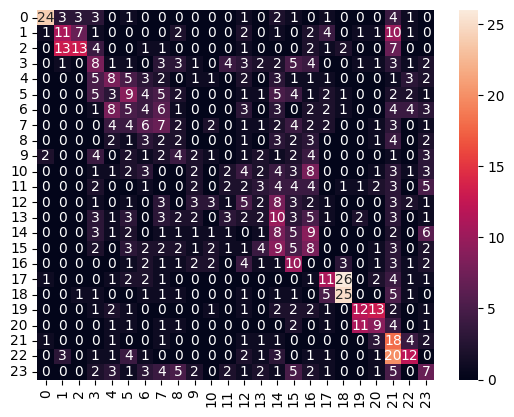

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.show()

In [89]:
y.shape

(5000,)

In [90]:
X_train, X_test, y_train, y_test, Z_train, Z_test = train_test_split(
    X, y, Z, test_size=0.2, random_state=42
)

In [91]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


In [92]:
snr_values = np.unique(Z_test)

acc_per_snr = []

for snr in snr_values:
    idx = np.where(Z_test == snr)[0]   # 🔥 important [0]
    
    acc = np.mean(y_pred[idx] == y_test[idx])
    acc_per_snr.append(acc)

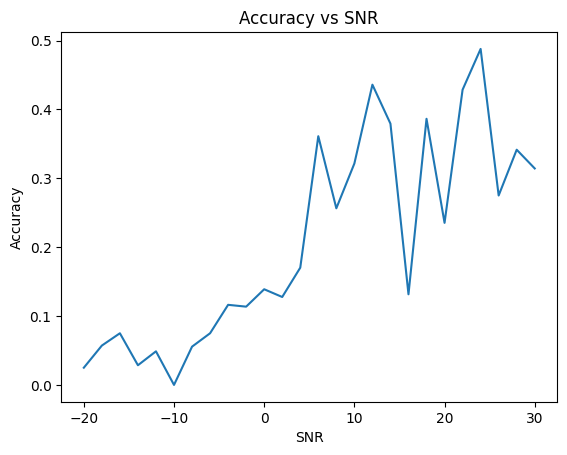

In [93]:
plt.plot(snr_values, acc_per_snr)
plt.xlabel("SNR")
plt.ylabel("Accuracy")
plt.title("Accuracy vs SNR")
plt.show()

In [94]:
for snr in snr_values:
    print(snr, np.sum(Z_test == snr))

-20 40
-18 35
-16 40
-14 35
-12 41
-10 37
-8 36
-6 40
-4 43
-2 44
0 36
2 47
4 47
6 36
8 39
10 28
12 39
14 29
16 38
18 44
20 34
22 35
24 41
26 40
28 41
30 35


In [95]:
import numpy as np

acc_per_snr_smooth = np.convolve(acc_per_snr, np.ones(3)/3, mode='same')

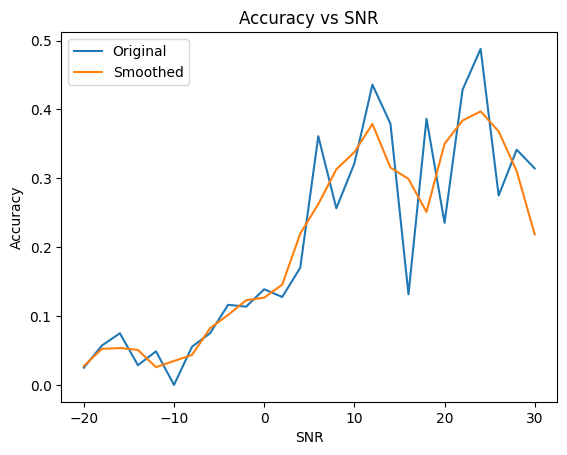

In [96]:
plt.plot(snr_values, acc_per_snr, label="Original")
plt.plot(snr_values, acc_per_snr_smooth, label="Smoothed")

plt.xlabel("SNR")
plt.ylabel("Accuracy")
plt.title("Accuracy vs SNR")
plt.legend()
plt.show()

In [102]:
classes = [
    'OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK',
    '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK',
    '16QAM', '32QAM', '64QAM', '128QAM', '256QAM',
    'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC',
    'FM', 'GMSK', 'OQPSK'
]

In [1]:
model.save("signal_classifier.h5")

NameError: name 'model' is not defined